# Where the stage equations have several solutions

An implicit Runge–Kutta step does not hand you the answer. It hands you a **nonlinear
equation** the stage values must satisfy — for the midpoint rule,

$$Y = y^n + \tfrac{\Delta t}{2}\, f(Y)$$

with $Y$ on both sides. Nonlinear equations can have several solutions.

**This matters because the RK-PINN loss is exactly zero at every one of them.** A classical
solver never notices: it starts Newton from a guess near $y^n$ and so always walks to the
solution continuously connected to $\Delta t \to 0$ — the *principal branch*, and the only one
Runge–Kutta order theory describes. A network has no starting guess.

> **This is a guardrail, not an object of study.** Its one job is to fix a ceiling on
> $\Delta t$. The experiments run well below it, where the stage solution is unique, and
> branches never arise.

Produced by `find_multiple_roots.py` and `map_where_solutions_merge.py` → `results/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent / "_shared"))
RESULTS, FIGURES = HERE / "results", HERE / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_EXACT, C_PRIN, C_SPUR = "#33322e", "#2a78d6", "#e34948"
print("cwd:", HERE.name)

from runge_kutta import reference
MU = 1.0
Y0 = np.array([2.0, 0.0])

cwd: multiple_stage_solutions


## 1. An exact case

At $q=1$ (implicit midpoint), $\Delta t = 2$, $y^n = (2,0)$, the stage equation gives
$Y_1 = 2 + Y_2$. Substituting reduces it **exactly** to

$$Y_1\,(Y_1 - 1)^2 = 0$$

a **double root** at $Y_1 = 1$ and a simple root at $Y_1 = 0$. Two solutions have collided.
There the stage Jacobian $J = \begin{pmatrix} 1 & -1 \\ -1 & 1\end{pmatrix}$ is exactly
singular.

Along that line the residual is exactly $r = Y_1(Y_1-1)^2$, so

$$\mathrm{SSE} = \big[Y_1 (Y_1-1)^2\big]^2 \;\sim\;
  \begin{cases} Y_1^2 & \text{near the simple root} \\[2pt]
                (Y_1-1)^4 & \text{near the double root} \end{cases}$$

Quadratic at a simple root, **quartic** at the merge. Reaching $\mathrm{SSE} = \varepsilon$
leaves you $\varepsilon^{1/2}$ from a simple root but only $\varepsilon^{1/4}$ from a merged
one — half the digits becomes a quarter, and descent stalls.

,root,Y1,Y2,residual,smallest_sv,multiplicity,is_fold
0,Y1=0,0.0,-2.0,0.0,0.618034,1,False
1,Y1=1,1.0,-1.0,0.0,0.000000,2,True


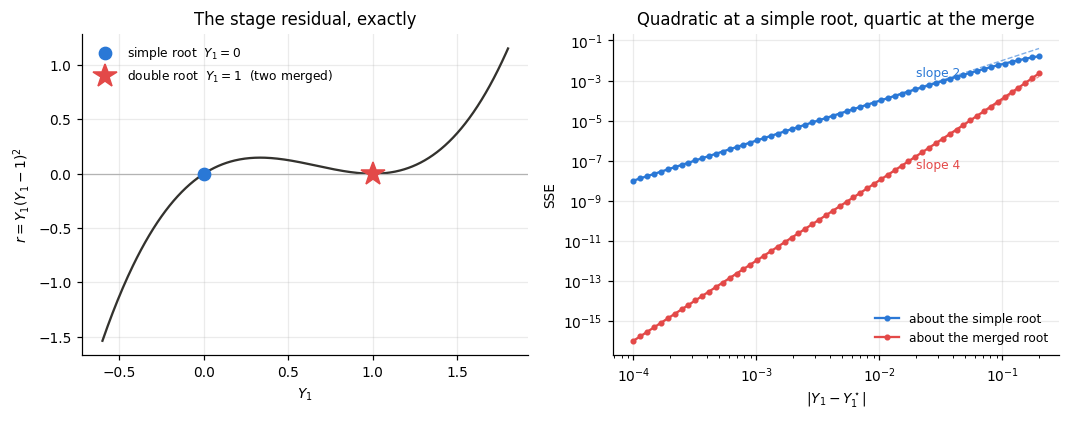

both roots verified at residual exactly 0.0; the double root's Jacobian is singular


In [2]:
fq = pd.read_csv(RESULTS / "exact_double_root.csv")
display(fq)

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.9))

y1 = np.linspace(-0.6, 1.8, 400)
axes[0].plot(y1, y1 * (y1 - 1) ** 2, color=C_EXACT)
axes[0].axhline(0, color="0.7", lw=0.8)
axes[0].plot([0], [0], "o", color=C_PRIN, ms=8, label="simple root  $Y_1=0$")
axes[0].plot([1], [0], "*", color=C_SPUR, ms=16,
             label="double root  $Y_1=1$  (two merged)")
axes[0].set_xlabel("$Y_1$"); axes[0].set_ylabel("$r = Y_1(Y_1-1)^2$")
axes[0].set_title("The stage residual, exactly"); axes[0].legend(fontsize=8)

d = np.logspace(-4, -0.7, 60)
axes[1].loglog(d, (d * (d - 1) ** 2) ** 2, "o-", ms=3, color=C_PRIN,
               label="about the simple root")
axes[1].loglog(d, ((1 + d) * d ** 2) ** 2, "o-", ms=3, color=C_SPUR,
               label="about the merged root")
axes[1].loglog(d, d ** 2, "--", lw=0.9, color=C_PRIN, alpha=0.6)
axes[1].loglog(d, d ** 4, "--", lw=0.9, color=C_SPUR, alpha=0.6)
axes[1].text(2e-2, 1.5e-3, "slope 2", color=C_PRIN, fontsize=8)
axes[1].text(2e-2, 4e-8, "slope 4", color=C_SPUR, fontsize=8)
axes[1].set_xlabel(r"$|Y_1 - Y_1^\star|$"); axes[1].set_ylabel("SSE")
axes[1].set_title("Quadratic at a simple root, quartic at the merge")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIGURES / "exact_double_root.png"); plt.show()

assert bool(fq[fq.multiplicity == 2].is_fold.iloc[0]), "the double root should be singular"
print("both roots verified at residual exactly 0.0; the double root's Jacobian is singular")

## 2. Three solutions, and the loss cannot tell them apart

At $q=2$, $\Delta t = 4$ the stage equations have at least three solutions. Random starts reach
all of them, and **every one is an exact global minimum of the loss** (SSE $\sim 10^{-19}$).

Newton, started from an RK4 predictor, selects the principal branch. Note that the root
*nearest* the true $y(4)$ is **not** the principal one — so proximity to the truth does not
identify the correct branch, and the loss, being zero at all of them, cannot either.

A classical solver picks the branch through its initial guess. **The RK-PINN loss has no such
device.**

,root,y_next_1,y_next_2,sse,is_principal,dist_to_exact
0,0,-2.817685,3.925761,2.510136e-19,False,3.472006
1,1,-1.929101,-1.170854,8.989481e-20,True,1.805266
2,2,-1.684253,0.240602,2.904382e-19,False,0.388347


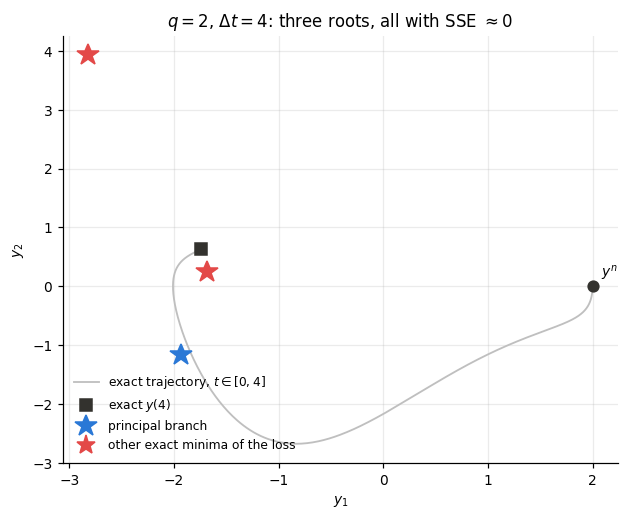

nearest the exact solution: root 2, principal = False
max SSE over the three roots = 2.9e-19  (all are global minima)


In [3]:
br = pd.read_csv(RESULTS / "distinct_roots.csv")
display(br)

sol = reference(Y0, 4.0, MU)
traj = np.array([sol.sol(t) for t in np.linspace(0, 4, 600)])
exact = sol.sol(4.0)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
ax.plot(traj[:, 0], traj[:, 1], "-", color="0.75", lw=1.2,
        label=r"exact trajectory, $t\in[0,4]$")
ax.plot(*Y0, "o", color=C_EXACT, ms=7); ax.annotate("$y^n$", Y0 + [0.08, 0.15])
ax.plot(*exact, "s", color=C_EXACT, ms=8, label="exact $y(4)$")
for r in br.itertuples():
    ax.plot(r.y_next_1, r.y_next_2, "*", ms=15,
            color=C_PRIN if r.is_principal else C_SPUR,
            label="principal branch" if r.is_principal else None)
ax.plot([], [], "*", color=C_SPUR, ms=13, label="other exact minima of the loss")
ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$")
ax.set_title(r"$q=2$, $\Delta t=4$: three roots, all with SSE $\approx 0$")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout(); fig.savefig(FIGURES / "distinct_roots.png"); plt.show()

n = br.loc[br.dist_to_exact.idxmin()]
print(f"nearest the exact solution: root {int(n.root)}, principal = {bool(n.is_principal)}")
print(f"max SSE over the three roots = {br.sse.max():.1e}  (all are global minima)")
assert not bool(n.is_principal), "the nearest root is expected NOT to be the principal one"

## 3. Where the merge happens, across the sampling region

Continuation in $\Delta t$ along the principal branch from each $y^n \in D$, warm-starting
Newton from the previous step. A cold start would silently jump branches — the very failure
being measured.

Grey means no merge was met below $\Delta t = 3$.

,q,earliest_fold,at_y1,at_y2,frac_safe_dt1,frac_safe_dt2
0,2,1.60,-2.083333,2.5,1.0,0.976331
1,4,2.76,-0.833333,3.0,1.0,1.000000
2,8,inf,NaN,NaN,1.0,1.000000


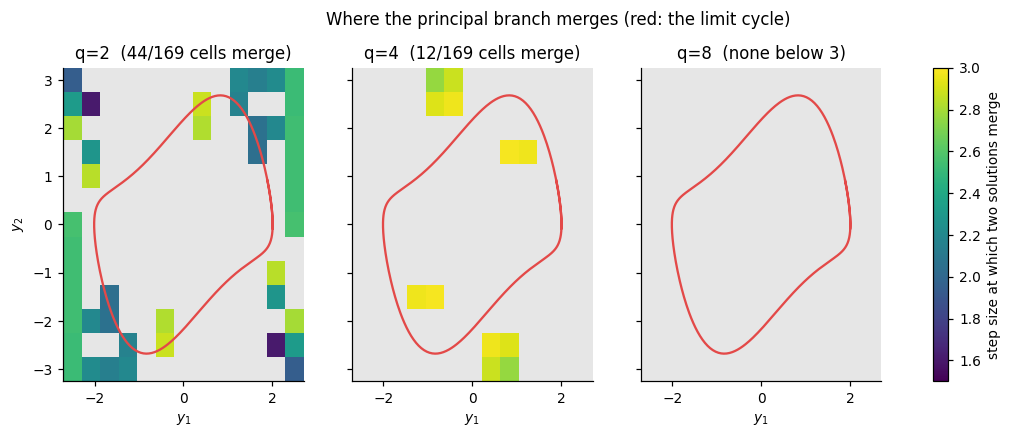

Merges cluster on the boundary of D, away from the limit cycle -- reassuring
for the long-rollout study, where trajectories settle onto the cycle.


In [4]:
import copy
surf = pd.read_csv(RESULTS / "merge_map.csv")
summ = pd.read_csv(RESULTS / "merge_summary.csv")
display(summ)

qs = sorted(surf.q.unique())
cmap = copy.copy(plt.get_cmap("viridis")); cmap.set_bad("0.90")

sol = reference(np.array([2.0, 0.0]), 60.0, MU)      # settle onto the limit cycle
lc = np.array([sol.sol(t) for t in np.linspace(53, 60, 600)])

fig, axes = plt.subplots(1, len(qs), figsize=(4.0 * len(qs), 3.7), sharey=True)
for ax, q in zip(np.atleast_1d(axes), qs):
    g = surf[surf.q == q]
    P = np.ma.masked_invalid(g.pivot(index="y2", columns="y1", values="fold_dt").values)
    im = ax.pcolormesh(sorted(g.y1.unique()), sorted(g.y2.unique()), P,
                       cmap=cmap, vmin=1.5, vmax=3.0, shading="nearest")
    ax.plot(lc[:, 0], lc[:, 1], "-", color=C_SPUR, lw=1.5)
    n_merge = int(np.isfinite(g.fold_dt).sum())
    ax.set_title(f"q={q}" + ("  (none below 3)" if n_merge == 0
                             else f"  ({n_merge}/{len(g)} cells merge)"))
    ax.set_xlabel("$y_1$"); ax.grid(False)
np.atleast_1d(axes)[0].set_ylabel("$y_2$")
fig.colorbar(im, ax=list(np.atleast_1d(axes)),
             label=r"step size at which two solutions merge")
fig.suptitle("Where the principal branch merges (red: the limit cycle)", y=1.02)
fig.savefig(FIGURES / "merge_map.png", bbox_inches="tight"); plt.show()

print("Merges cluster on the boundary of D, away from the limit cycle -- reassuring")
print("for the long-rollout study, where trajectories settle onto the cycle.")

**Larger $q$ pushes the merge out.** That is a second reason the paper's large-$q$
regime works, independent of the order being $2q$, and it is consistent with Raissi taking
$q = 100$ at $\Delta t = 0.8$ on Allen–Cahn.

The classical *sufficient* condition for a unique stage solution,
$\Delta t\, L \max_i \sum_j |a_{ij}| < 1$, predicts the **opposite** trend: with $L = 16.8$ on
$D$ it guarantees nothing past $\Delta t \approx 0.12$, and it tightens with $q$ because
$\max_i \sum_j |a_{ij}| \to 1$. Merely sufficient, and useless here.

## What this fixes

$\Delta t = 0.8$ for the experiments — a factor of two below the earliest merge anywhere in
$D$ (which is $1.60$, at $q=2$). At that step the stage solution is unique, and by $q = 8$ the
scheme's own error is $\sim 10^{-12}$, far below anything a network reaches. **So the error we
go on to measure is the network's**, which is the object of the study.

> **Caveat.** A $13\times13$ grid, continuation step $0.02$, singular-value tolerance
> $10^{-2}$, up to $\Delta t = 3$, at $\mu = 1$, for $q \in \{2,4,8\}$ only. A grid gives an
> **upper** bound on the earliest merge in $D$; nothing is known above $\Delta t = 3$; and
> $q = 1$ was never mapped over $D$. Stiffness moves the ceiling, so re-measure before raising
> $\mu$. Measured, not proved.

In [5]:
safe = 0.8
earliest = summ.earliest_fold.min()
print(f"earliest merge anywhere in D, over q in {sorted(summ.q)}: dt = {earliest:.2f}")
print(f"chosen step size for the experiments:                    dt = {safe}")
print(f"margin: {earliest / safe:.2f}x")
assert safe < earliest / 1.5, "the chosen step size is not comfortably below the merge"

earliest merge anywhere in D, over q in [2, 4, 8]: dt = 1.60
chosen step size for the experiments:                    dt = 0.8
margin: 2.00x
